In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv('./placement.csv')

In [3]:
df.sample(5)

,cgpa,placement_exam_marks,placed
562,6.06,23.0,0
222,6.97,78.0,0
924,6.85,23.0,1
102,5.92,22.0,1
891,7.42,26.0,1


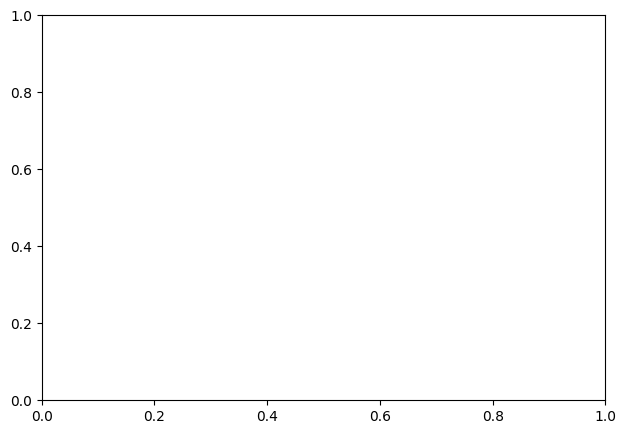

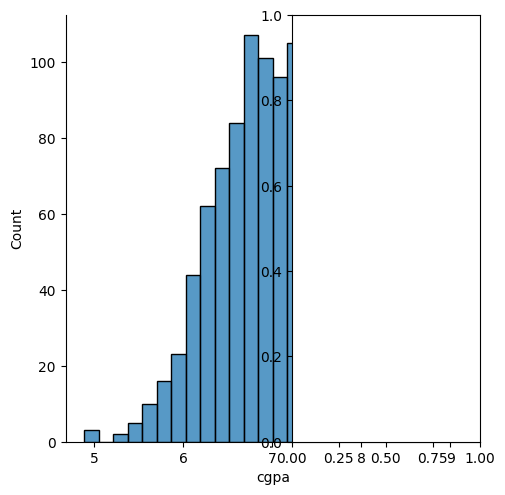

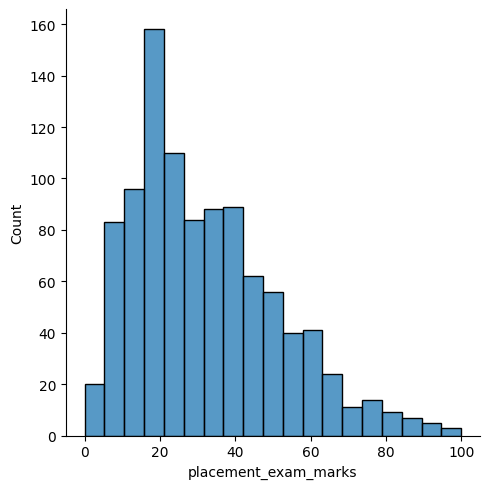

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])



plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])

plt.show()

In [5]:
# finding the range values 

print("highest allowed",df['cgpa'].mean()+3*df["cgpa"].std())
print("lowest allowed",df['cgpa'].mean()-3*df["cgpa"].std())


highest allowed 8.808933625397168
lowest allowed 5.113546374602832


In [ ]:
# outlier detection 

df[( df['cgpa']> 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [8]:
# removal of the outlier

# 1. trimming 

new_df = df[( df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [10]:
# approach 2 ( z score method )

# caclulating the z score 

df["z_score"] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [11]:
df.head()

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [13]:
df[(df['z_score'] > 3) | (df['z_score'] < -3)]

,cgpa,placement_exam_marks,placed,z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
# Trimming 
new_df = df[(df['z_score'] < 3) & (df['z_score'] > -3)]

new_df

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [17]:
# capping 

upperLimit = df['cgpa'].mean()+3*df["cgpa"].std()
lowerLimit = df['cgpa'].mean()-3*df["cgpa"].std()


In [19]:
lowerLimit

np.float64(5.113546374602832)

In [20]:
upperLimit

np.float64(8.808933625397168)

In [22]:

df["cgpa"] = np.where(
    df['cgpa'] > upperLimit,
    upperLimit,
    np.where(
        df['cgpa'] < lowerLimit,
        lowerLimit,
        df['cgpa']
    )
)

In [24]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64